In [1]:
import base64
import cv2
from moviepy import VideoFileClip
from dotenv import load_dotenv
from textwrap import dedent
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from langchain.tools import tool
from langchain_ollama import ChatOllama;
# from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import InMemorySaver
from tavily import TavilyClient
from typing import Dict, Any
from string import Template
import json
from pprint import pprint
# from langchain_mcp_adapters.client import MultiServerMCPClient
import yt_dlp
# from ipywidgets import FileUpload
# from IPython.display import display

# Get environment variables (API Keys) from .env file
load_dotenv()

# Optional choices to initialize local LLM models
llm = ChatOllama(model="gemma4:e4b", temperature=0, max_tokens=2048)
# To use an ML Studio model, you must redirect OpenAI in .zshrc as well
# llm = ChatOpenAI(base_url="http://localhost:1234/v1",
#                  api_key="Any-ol-string",
#                  model="qwen/qwen3.5-35b-a3b",
#                  streaming=True)
# llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0, max_tokens=2048)

config = {"configurable": {"thread_id": "1"}}

# Define a search tool via Tavily API
tavily_client = TavilyClient()
@tool
def web_search(query: str) -> Dict[str, Any]:
    """Search the web for information"""
    return tavily_client.search(query)

# Create a simple agent that uses the Ollama or OpenAI LLM
agent = create_agent(
    model=llm,
    tools=[web_search],
    checkpointer=InMemorySaver()
)

question = HumanMessage(content="What day is tomorrow? If you don't know today's date use search tool")

# response = agent.invoke(
#     {"messages": [question]},
#     config
# )

# pprint(response['messages'])

In [2]:
response = agent.invoke(
    {"messages": [question]},
    config
)

pprint(response['messages'])

[HumanMessage(content="What day is tomorrow? If you don't know today's date use search tool", additional_kwargs={}, response_metadata={}, id='5a97c801-bdd8-4217-9836-21b7493ab622'),
 AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gemma4:e4b', 'created_at': '2026-04-23T21:40:47.590164Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8209260708, 'load_duration': 6486019208, 'prompt_eval_count': 76, 'prompt_eval_duration': 136994125, 'eval_count': 108, 'eval_duration': 1461499953, 'logprobs': None, 'model_name': 'gemma4:e4b', 'model_provider': 'ollama'}, id='lc_run--019dbc49-b135-7b12-9ddb-83906b8ec742-0', tool_calls=[{'name': 'web_search', 'args': {'query': "today's date"}, 'id': '7948bd35-c41a-4294-ab38-5fed4eee29e7', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'output_tokens': 108, 'total_tokens': 184}),
 ToolMessage(content='{"query": "today\'s date", "follow_up_questions": null, "answer": null, "images": [], "re

In [3]:
INSTRUCTION = dedent("""
<Instruction>
You are an advanced AI trained to label social media posts related to crisis situations, specifically natural disasters.
Your goal is to label the given posts and social media videos.
                     
Hard rules:
Use visual evidence from attached video to classify the post.
Do not infer solely from title, description, transcript, hashtags, or prior knowledge.
If visual evidence is insufficient, explicitly return insufficient_visual_evidence.
Adhere to output formats strictly, ensuring all required fields are present in correctly formatted JSON.
                    
</Instruction>
""").strip()

TAXONOMY = {
    "Supplies": [
        "Transport",
        "Medical",
        "Water, Sanitation, and Hygiene (WASH)",
        "Shelter and Housing",
        "Equipment and Tools",
        "Food and Nutrition",
        "Clothing and Warmth",
        "Communication and Power",
        "Education and Recreation",
        "Money",
        "Infant Care",
    ],
    "Emergency Personnel": [
        "Search and Rescue Teams",
        "Medical and Health Teams",
        "Fire and Hazard Control",
        "Law Enforcement and Security",
        "Logistics and Coordination Teams",
        "Communication and IT Teams",
        "Shelter and Housing Teams",
        "Community and Social Support Teams",
        "Energy and Infrastructure Repair Teams",
        "Recovery and Rehabilitation Teams",
        "Legal and Advocacy Teams",
    ],
    "Actions": [
        "Search and Rescue",
        "Medical Assistance",
        "Shelter and Housing Support",
        "Food and Water Distribution",
        "Infrastructure Repair and Debris Clearance",
        "Transportation Services",
        "Security and Crowd Control",
        "Information and Communication",
        "Resource Coordination and Supply Management",
        "Community and Social Support",
        "Recovery and Rehabilitation",
    ],
}
taxonomy_json = json.dumps(TAXONOMY, indent=2)

In [4]:
FULL_TAXONOMY = {
    "Taxonomy": {
      "Supplies": {
        "Transport": [
          "Spare Parts",
          "Vehicles"
        ],
        "Medical": [
          "Wound Care and First Aid Supplies",
          "Tools, Accessories, and Protective Gear",
          "Medications and Treatment Supplies",
          "Diagnostic",
          "Respiratory Equipment",
          "Mobility Aids",
          "Laboratory Equipment",
          "Cold Chain and Temperature-Controlled Storage"
        ],
        "Water, Sanitation, and Hygiene (WASH)": [
          "Water Storage",
          "Borehole Construction",
          "Pumps",
          "Water Distribution",
          "Water Testing",
          "Water Treatment",
          "Sanitation Facilities",
          "Personal Hygiene",
          "Cleaning Supplies"
        ],
        "Shelter and Housing": [
          "Shelter",
          "Covers and Linings",
          "Accessories"
        ],
        "Equipment and Tools": [
          "IT and Office Supplies",
          "Emergency Tools",
          "Basic Tools",
          "Material Handling Equipment",
          "Kitchen Items"
        ],
        "Food and Nutrition": [
          "Staples",
          "Proteins",
          "Cooking Essentials",
          "High-Energy Foods",
          "Ready-to-Eat Foods",
          "Beverages",
          "Other Essentials"
        ],
        "Clothing and Warmth": [
          "Clothing",
          "Warmth Items",
          "Other Clothing"
        ],
        "Communication and Power": [
          "Communication Tools",
          "Power Supply",
          "Lighting"
        ],
        "Education and Recreation": [
          "Educational Supplies",
          "Recreational Items"
        ],
        "Money": [
        ],
        "Infant Care": [
          "Comfort Packs for Children",
          "Pacifiers",
          "Baby Carriers",
          "Trolleys"
        ]
      },
      "Emergency Personnel": {
        "Search and Rescue Teams": [
          "Urban Search and Rescue (USAR) teams",
          "Water Rescue Teams",
          "K9 Search Teams",
          "Mountain/High Angle Rescue",
          "Specialized Medical Rescuers"
        ],
        "Medical and Health Teams": [
          "Emergency Medical Technicians (EMTs)",
          "Paramedics",
          "Doctors",
          "Surgeons",
          "Psychosocial Support Teams",
          "Mental Health Professionals",
          "Infection Control Experts",
          "Public Health Teams"
        ],
        "Fire and Hazard Control": [
          "Firefighting Teams",
          "Hazardous Materials (HAZMAT) Teams",
          "Fire Safety Inspectors"
        ],
        "Law Enforcement and Security": [
          "Police Officers",
          "Military Police",
          "Community Liaison Officers",
          "Forensic Teams",
          "Evacuation Personnel"
        ],
        "Logistics and Coordination Teams": [
          "Disaster Coordination Officers",
          "Relief Operations Coordinators",
          "Transport and Supply Chain Teams",
          "Volunteers"
        ],
        "Communication and IT Teams": [
          "Emergency Communications Specialists",
          "Satellite Communications Technicians",
          "Public Information Officers",
          "Media Liaison Officers",
          "ICT Specialists"
        ],
        "Shelter and Housing Teams": [
          "Shelter Managers",
          "Emergency Housing Specialists",
          "Construction Teams"
        ],
        "Community and Social Support Teams": [
          "Child Protection Teams",
          "Gender-Based Violence (GBV) Specialists",
          "Elderly Care Specialists",
          "Community Outreach Workers"
        ],
        "Energy and Infrastructure Repair Teams": [
          "Electricians",
          "Water and Sanitation Technicians",
          "Road Construction Crews"
        ],
        "Recovery and Rehabilitation Teams": [
          "Reconstruction Teams",
          "Economic Recovery Teams",
          "Education Support Teams"
        ],
        "Legal and Advocacy Teams": [
          "Legal Aid Teams",
          "Advocacy Teams"
        ]
      },
      "Actions": {
        "Search and Rescue": [
          "Search for Missing Persons",
          "Evacuation Support",
          "Water Rescue"
        ],
        "Medical Assistance": [
          "First Aid and Triage",
          "Hospitalization and Treatment",
          "Psychosocial and Mental Health"
        ],
        "Shelter and Housing Support": [
          "Setting Up Temporary Shelters",
          "Repair and Retrofitting"
        ],
        "Food and Water Distribution": [
          "Food Aid",
          "Water Supply"
        ],
        "Infrastructure Repair and Debris Clearance": [
          "Road and Bridge Clearing",
          "Utility Restoration",
          "Debris Removal"
        ],
        "Transportation Services": [
          "Evacuation Transport",
          "Ambulance and Medical Transport",
          "Supply and Personnel Transport"
        ],
        "Security and Crowd Control": [
          "Patrol and Perimeter Security",
          "Traffic and Crowd Management",
          "Incident Control Points"
        ],
        "Information and Communication": [
          "Public Announcements and Alerts",
          "Misinformation Management",
          "Hotline or Helpline Operation",
          "Translation and Interpretation Services"
        ],
        "Resource Coordination and Supply Management": [
          "Warehouse and Inventory Control",
          "Last-Mile Distribution",
          "Volunteer and Donations Management"
        ],
        "Community and Social Support": [
          "Child-Friendly Spaces",
          "Gender-Based Violence (GBV) Response",
          "Elderly and Special Needs Support",
          "Family Reunification"
        ],
        "Recovery and Rehabilitation": [
          "Livelihood Recovery",
          "Education Continuity",
          "Community Rehabilitation"
        ]
      }
    }
  }

full_taxonomy_json = json.dumps(FULL_TAXONOMY, indent=2)

In [5]:
CONTEXT = Template(dedent("""
<Context>
Natural disasters, such as hurricanes, wildfires, earthquakes, floods, tornadoes, landslides, etc. have significant impacts on communities.

Each social media post of type Offer or Request can be represented as a triplet of themes: supplies, personnel, actions.

<Taxonomy>
$taxonomy_json
</Taxonomy>

this is a more detailed version of the taxonomy to understand the components of the classes, do not use these as the target labels, but as a way to understand the taxonomy:

<Full Taxonomy>
$full_taxonomy_json
</Full Taxonomy>

The social media data should be categorized into its specific type (Request, Offer, Other) and should be labeled based on supplies, action, emergency personnel.
</Context>
""").strip())

In [6]:
OUTPUT_FORMATS = dedent("""
<Output formats>
this is the output format when the type is either Request or Offer or both:
{
  "text": "The social media post text here",
  "type": ["Request"],
  "action_request": [],
  "personnel_request": [],
  "supplies_request": [],
  "action_offer": [],
  "personnel_offer": [],
  "supplies_offer": [],
  "actionability": false,
  "explanation": "...",
  "visual_evidence": "...",
  "confidence": 0.0 to 1.0,
  "insufficient_visual_evidence": true or false
}

this is the output format when the type is Other:
{
  "text": "The social media post text here",
  "type": ["Other"],
  "explanation": "..."
  "visual_evidence": "...",
  "confidence": 0.0 to 1.0,
  "insufficient_visual_evidence": true or false             
}

</Output formats>
                        

""").strip()

In [7]:
AMBIGUOUS_CLASSES = dedent("""
<ambiguous classes>
Supplies:
- Transport: Label posts as "transport" when they mention specific transport-related supplies or items associated with transportation vehicles.
- Equipment and Tools: Apply this label when posts involve the request or donation of tools and equipment.
- Shelter and Housing: This label applies to posts referencing places where people can stay or live.

Actions:
- Resource Coordination and Supply Management: Use this label for posts focused on the distribution, management, collection, or organization of supplies and resources.
- Information and Communication: Apply this label to posts that involve requesting advice or information, as well as those offering critical information.
- Recovery and Rehabilitation: Use this label for posts concerning actions after a disaster, focused on returning to normal life.
- Search and Rescue: Label posts as "Search and Rescue" if they involve requests for or offers of assistance in locating missing individuals or rescuing people.
- Community and Social Support: Use this label for posts that focus on providing support to vulnerable populations.

Emergency Personnel:
- Logistics and Coordination Teams: Teams or volunteers responsible for distributing supplies or managing logistics.
- Recovery and Rehabilitation Teams: Groups focused on medium- and long-term recovery.
- Shelter and Housing Teams: Teams who assist in setting up, repairing, or providing shelters and housing.
- Legal and Advocacy Teams: Individuals, professionals, or volunteers offering assistance with legal matters.
</ambiguous classes>
""").strip()

In [8]:
STOCK_EXAMPLES = dedent("""
{
  "text": "If anyone knows how to contact ppl in Aab Barik, plz DM. Worried sick. #AfghanLandslides",
  "type": ["Request"],
  "action_request": ["Information and Communication"],
  "personnel_request": [],
  "supplies_request": [],
  "action_offer": [],
  "personnel_offer": [],
  "supplies_offer": [],
  "actionability": false,
  "explanation": "Seeking personal contact info; not an urgent supply or rescue request."
}

{
  "text": "Does anyone know how to access the wildfire relief fund? The site keeps crashing. #CaliforniaFires",
  "type": ["Request"],
  "action_request": ["Information and Communication"],
  "personnel_request": [],
  "supplies_request": [],
  "action_offer": [],
  "personnel_offer": [],
  "supplies_offer": [],
  "actionability": false,
  "explanation": "Asking for instructions on relief fund site; no urgency or location."
}
""").strip()

In [9]:
PROMPT_TEMPLATE = Template(dedent("""
$instruction

$context

$output_formats

$ambiguous_classes

<Examples>
These are few examples of the classification:
$stock_examples
$additional_examples
</Examples>

<Task>
Your task is to label the following social media post based on the taxonomy and rules mentioned above.
Only output the json dictionary and nothing else.
Take into account the ambiguous classes.
</Task>

social media title and description: $post
social media video attached as video.
""").strip())

In [ ]:
# post_text = "I have a spare generator that can be used for power supply. DM me if you need it. #CaliforniaFires"

In [10]:
pprint(response["messages"][-2:])

[ToolMessage(content='{"query": "today\'s date", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://isotropic.org/date/", "title": "Today\'s Date - isotropic.org", "content": "Gregorian: Thursday, 23 April 2026 ; Mayan: Long count = 13.0.13.9.11; tzolkin = 13 Chuen; haab = 4 Uo ; French: 4 Floréal an 234 de la Révolution ; Islamic: 6 Dhu", "score": 0.9946568, "raw_content": null}, {"url": "https://www.inchcalculator.com/what-is-todays-date/", "title": "What Is Today\'s Date? - Inch Calculator", "content": "Today, April 22nd , is day 112 of 365 total days in 2026. What is Today\'s Date in Numbers? Today\'s date in numbers is: MM-DD-YYYY: 04-22-2026; DD-MM-YYYY:", "score": 0.9863631, "raw_content": null}, {"url": "https://www.calendardate.com/todays.htm", "title": "Today\'s Date - CalendarDate.com", "content": "Details about today\'s date with count of days, weeks, and months, Sun and Moon cycles, Zodiac signs and holidays.", "score": 0.98582757, "raw

In [11]:
DOWNLOAD = False
url1 = "https://www.tiktok.com/@nbcnews/video/7619508960864832782?q=Hawaii%20Flood&t=1775163541548"
url2 = "https://www.tiktok.com/@_orgena444/video/7466112076805623070?q=%23hawaiifloods&t=1775615126915"
url3 = "https://www.tiktok.com/@caryshicks/video/7619292995883404575?q=%23HawaiiFloods%20need&t=1775616053268"
yt_dlp_info = yt_dlp.YoutubeDL().extract_info(url3, download=DOWNLOAD)
pprint(yt_dlp_info)
print(yt_dlp_info['title'])

[TikTok] Extracting URL: https://www.tiktok.com/@caryshicks/video/7619292995883404575?q=%23HawaiiFloods%20need&t=1775616053268
[TikTok] 7619292995883404575: Downloading webpage


{'_has_drm': None,
 'abr': None,
 'acodec': 'aac',
 'artist': 'Carys | Oahu Photographer',
 'artists': ['Carys | Oahu Photographer'],
 'aspect_ratio': 0.56,
 'audio_ext': 'none',
 'channel': 'Carys | Oahu Photographer',
 'channel_id': 'MS4wLjABAAAA6-_SorliyFz5hH8Rc6iu14-mOBVJs7-9IMR0mBpost8t_0injB8CfEPNxXk2y2V4',
 'channel_url': 'https://www.tiktok.com/@MS4wLjABAAAA6-_SorliyFz5hH8Rc6iu14-mOBVJs7-9IMR0mBpost8t_0injB8CfEPNxXk2y2V4',
 'comment_count': 8358,
 'cookies': 'ttwid=1%7ClaxdHaLML28SBxH_chNOlPxU6eeTxmw8GKy-UXxwD9Y%7C1776980458%7C60b72bc15b633206348030c2bd6ad759ef8673e9a133f2166ccbd77ff8a3ccdd; '
            'Domain=.tiktok.com; Path=/; Secure; Expires=1808084458; '
            'tt_csrf_token=cOvf1WJr-nCvIqw_0e3AgLUZIzVUPIcUKR44; '
            'Domain=.tiktok.com; Path=/; Secure; '
            'tt_chain_token="JFIr1JDeSBOn/IRvkgtJBw=="; Domain=.tiktok.com; '
            'Path=/; Secure; Expires=1792532459',
 'description': 'a loud crash then a massive flash flood #flashflood #hawa

In [12]:
pprint(yt_dlp_info)

{'_has_drm': None,
 'abr': None,
 'acodec': 'aac',
 'artist': 'Carys | Oahu Photographer',
 'artists': ['Carys | Oahu Photographer'],
 'aspect_ratio': 0.56,
 'audio_ext': 'none',
 'channel': 'Carys | Oahu Photographer',
 'channel_id': 'MS4wLjABAAAA6-_SorliyFz5hH8Rc6iu14-mOBVJs7-9IMR0mBpost8t_0injB8CfEPNxXk2y2V4',
 'channel_url': 'https://www.tiktok.com/@MS4wLjABAAAA6-_SorliyFz5hH8Rc6iu14-mOBVJs7-9IMR0mBpost8t_0injB8CfEPNxXk2y2V4',
 'comment_count': 8358,
 'cookies': 'ttwid=1%7ClaxdHaLML28SBxH_chNOlPxU6eeTxmw8GKy-UXxwD9Y%7C1776980458%7C60b72bc15b633206348030c2bd6ad759ef8673e9a133f2166ccbd77ff8a3ccdd; '
            'Domain=.tiktok.com; Path=/; Secure; Expires=1808084458; '
            'tt_csrf_token=cOvf1WJr-nCvIqw_0e3AgLUZIzVUPIcUKR44; '
            'Domain=.tiktok.com; Path=/; Secure; '
            'tt_chain_token="JFIr1JDeSBOn/IRvkgtJBw=="; Domain=.tiktok.com; '
            'Path=/; Secure; Expires=1792532459',
 'description': 'a loud crash then a massive flash flood #flashflood #hawa

In [13]:
def prepare_gemma4_input(video_path, fps=1):
    """
    Extracts frames and audio from a video file for Gemma 4.
    """
    inputs = []
    
    # # --- 1. Extract Audio ---
    # # Gemma 4:e4b accepts audio tokens (base64 encoded)
    # video_clip = VideoFileClip(video_path)
    # audio_path = "temp_audio.mp3"
    # video_clip.audio.write_audiofile(audio_path, logger=None)
    
    # with open(audio_path, "rb") as f:
    #     audio_b64 = base64.b64encode(f.read()).decode("utf-8")
    
    # inputs.append({
    #     "type": "input_audio", 
    #     "input_audio": {"data": audio_b64, "format": "mp3"}
    # })
    
    # --- 2. Extract Frames ---
    video = cv2.VideoCapture(video_path)
    video_fps = video.get(cv2.CAP_PROP_FPS)
    frame_interval = int(video_fps / fps)
    
    success, frame_count = True, 0
    while success:
        success, frame = video.read()
        if success and frame_count % frame_interval == 0:
            # Resize for efficiency (Gemma 4 likes 448x448 or 720p)
            _, buffer = cv2.imencode(".jpg", frame)
            img_b64 = base64.b64encode(buffer).decode("utf-8")
            inputs.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}
            })
        frame_count += 1
        
    video.release()
    # os.remove(audio_path) # Clean up
    return inputs

a loud crash then a massive flash flood #flashflood #hawaii #oahu #no... [7619292995883404575].mp4
[{'image_url': {'url': ''},
  'type': 'image_url'},
 {'image_url': {'url': ''},
  'type': 'image_url'},
 {'image_url': {'url': ''},
  'type': 'image_url'},
 {'image_url': {'url': ''},
  'type': 'image_url'},
 {'image_url': {'url': ''},
  'type': 'image_url'},
 {'image_url': {'url': ''},
  'type': 'image_url'},
 {'image_url': {'url': ''},
  'type': 'image_url'},
 {'image_url': {'url': ''},
  'type': 'image_url'},
 {'image_url': {'url': ''},
  'type': 'image_url'},
 {'image_url': {'url': ''},
  'type': 'image_url'},
 {'image_url': {'url': ''},
  'type': 'image_url'},
 {'image_url': {'url': ''},
  'type': 'image_url'}]

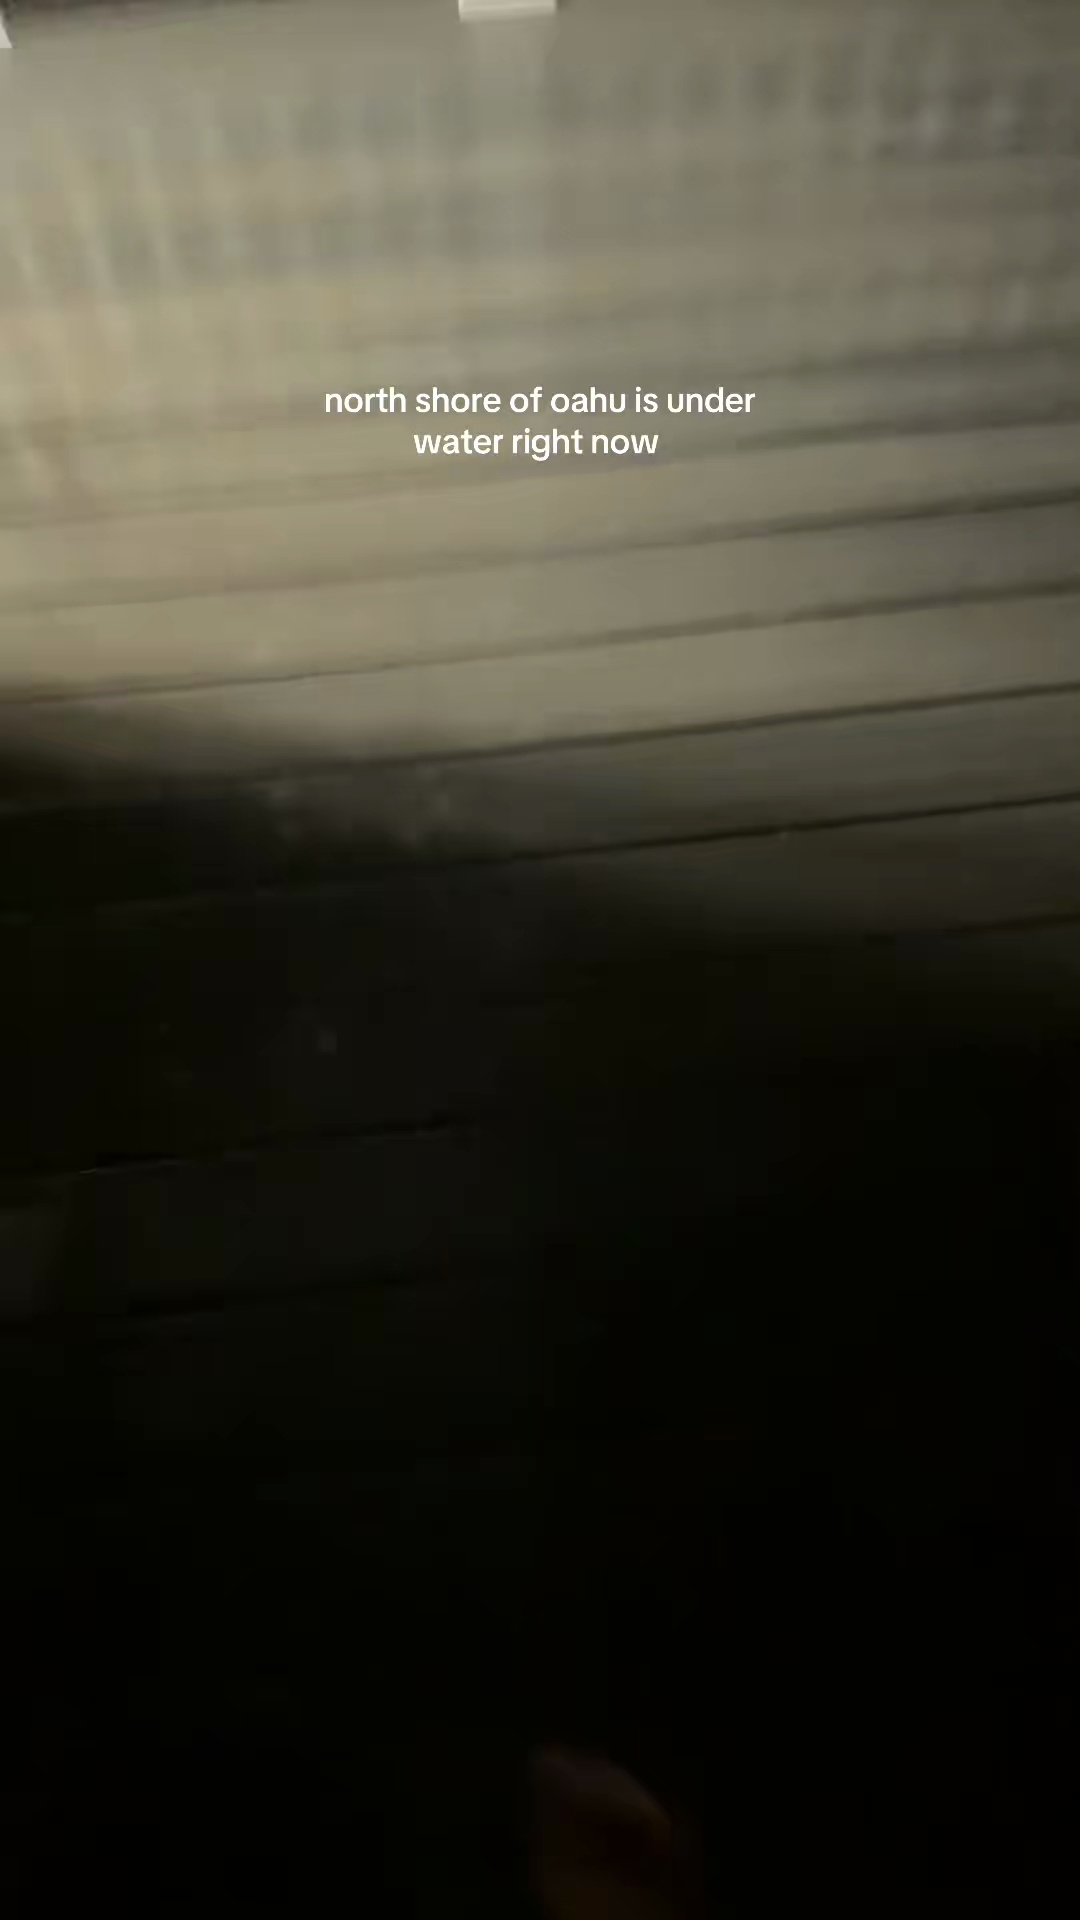
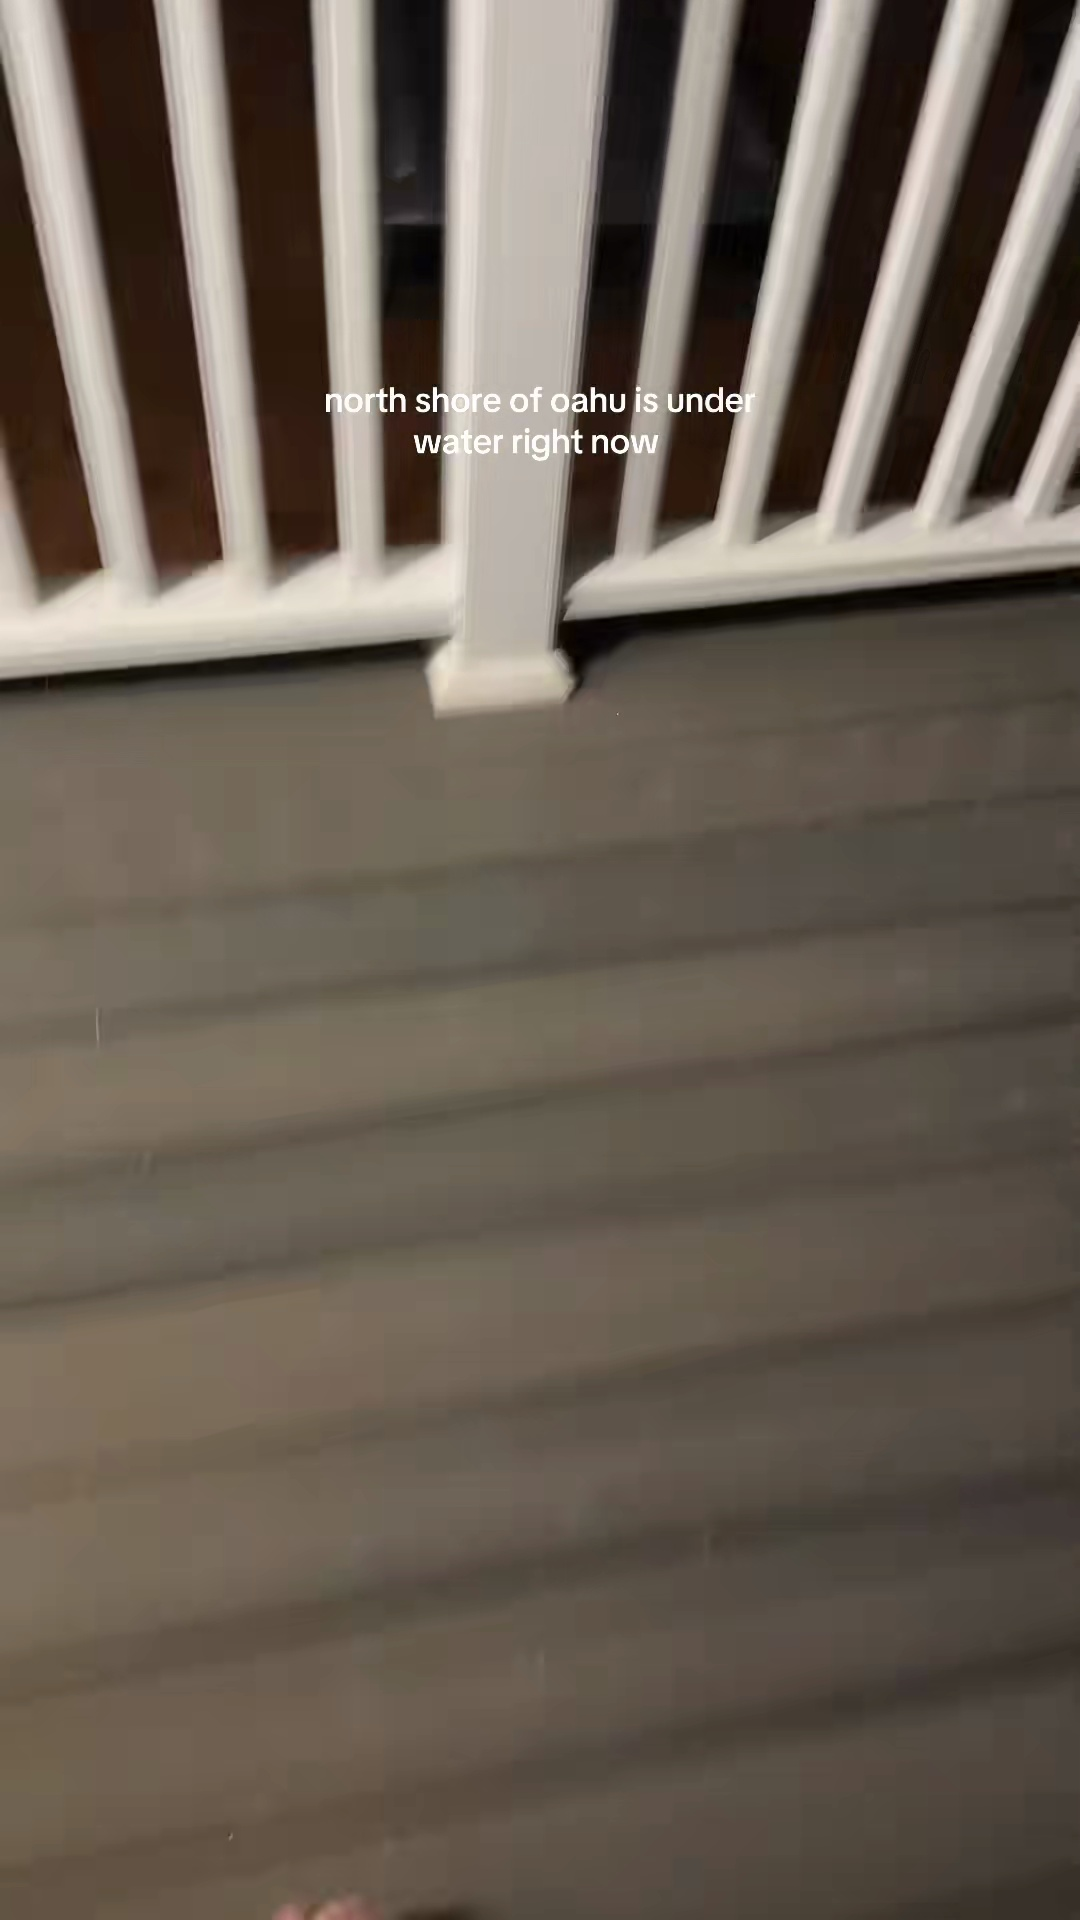
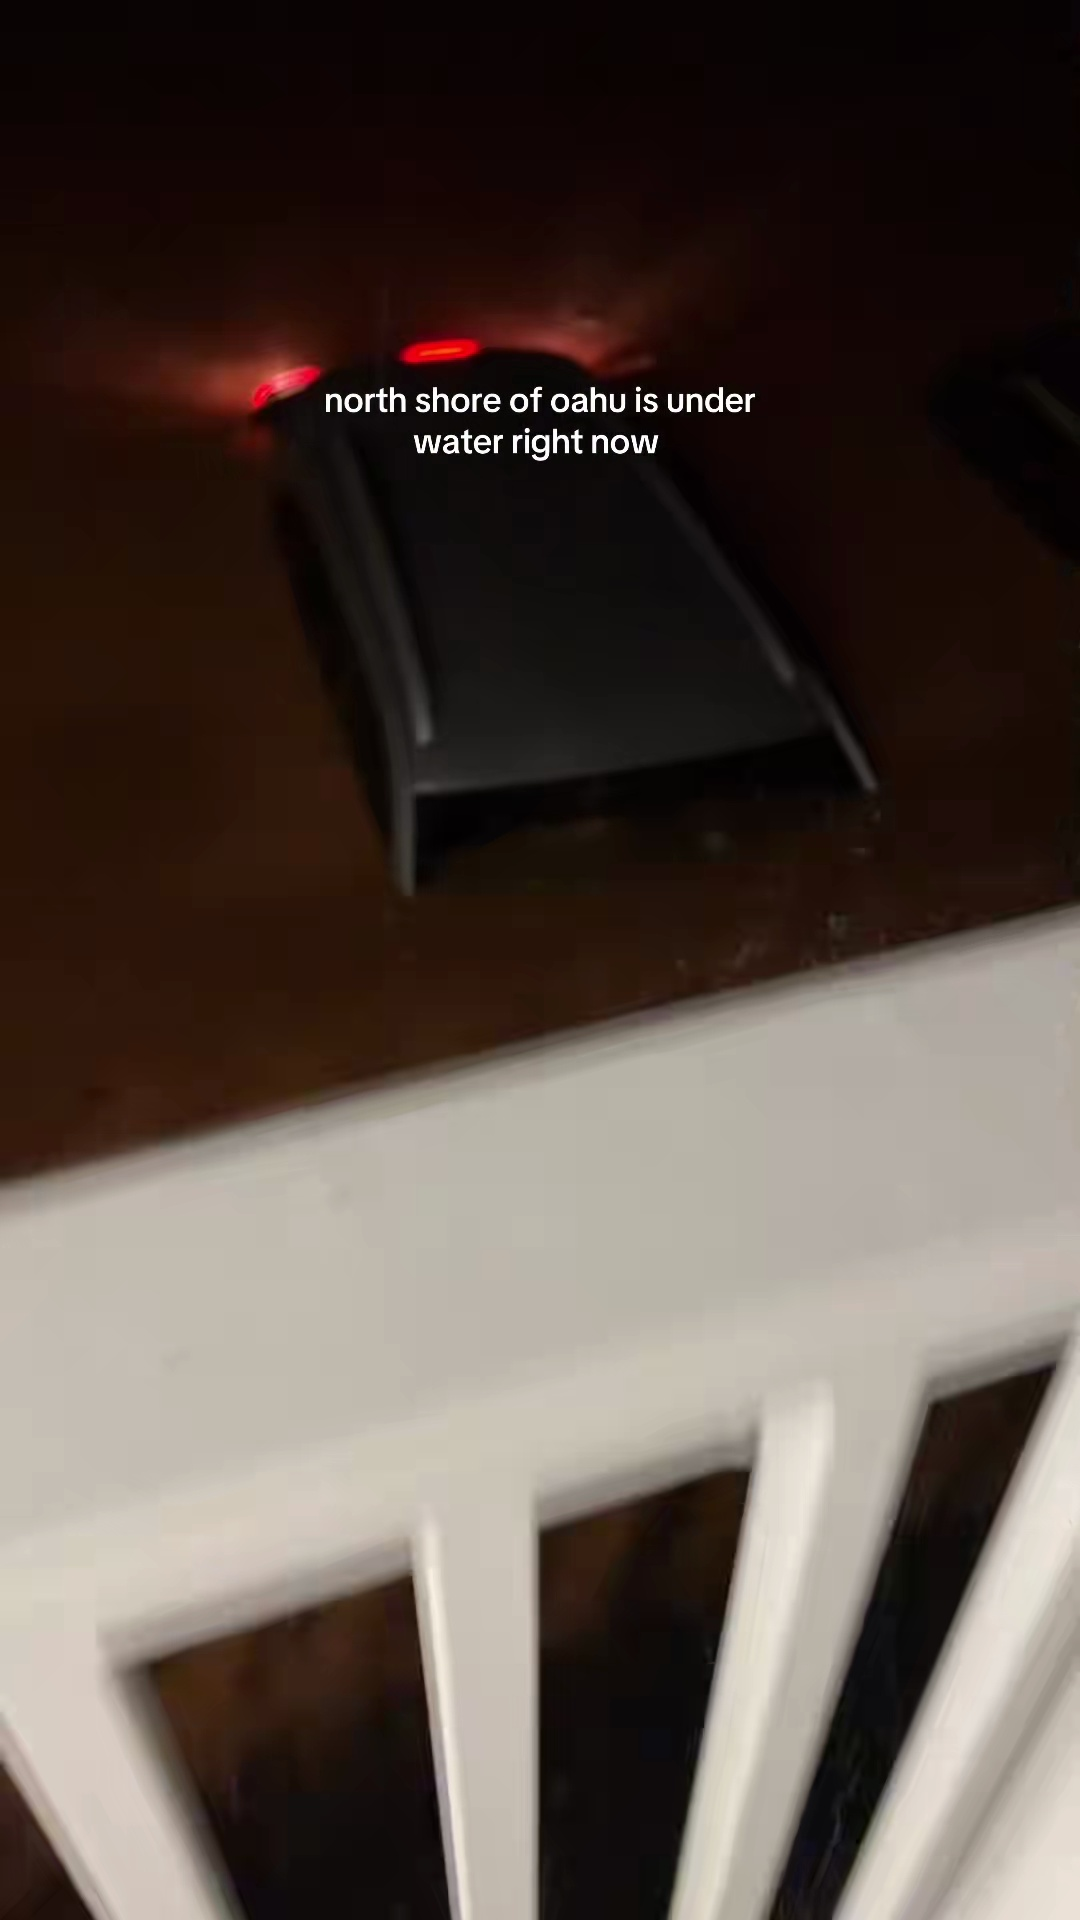
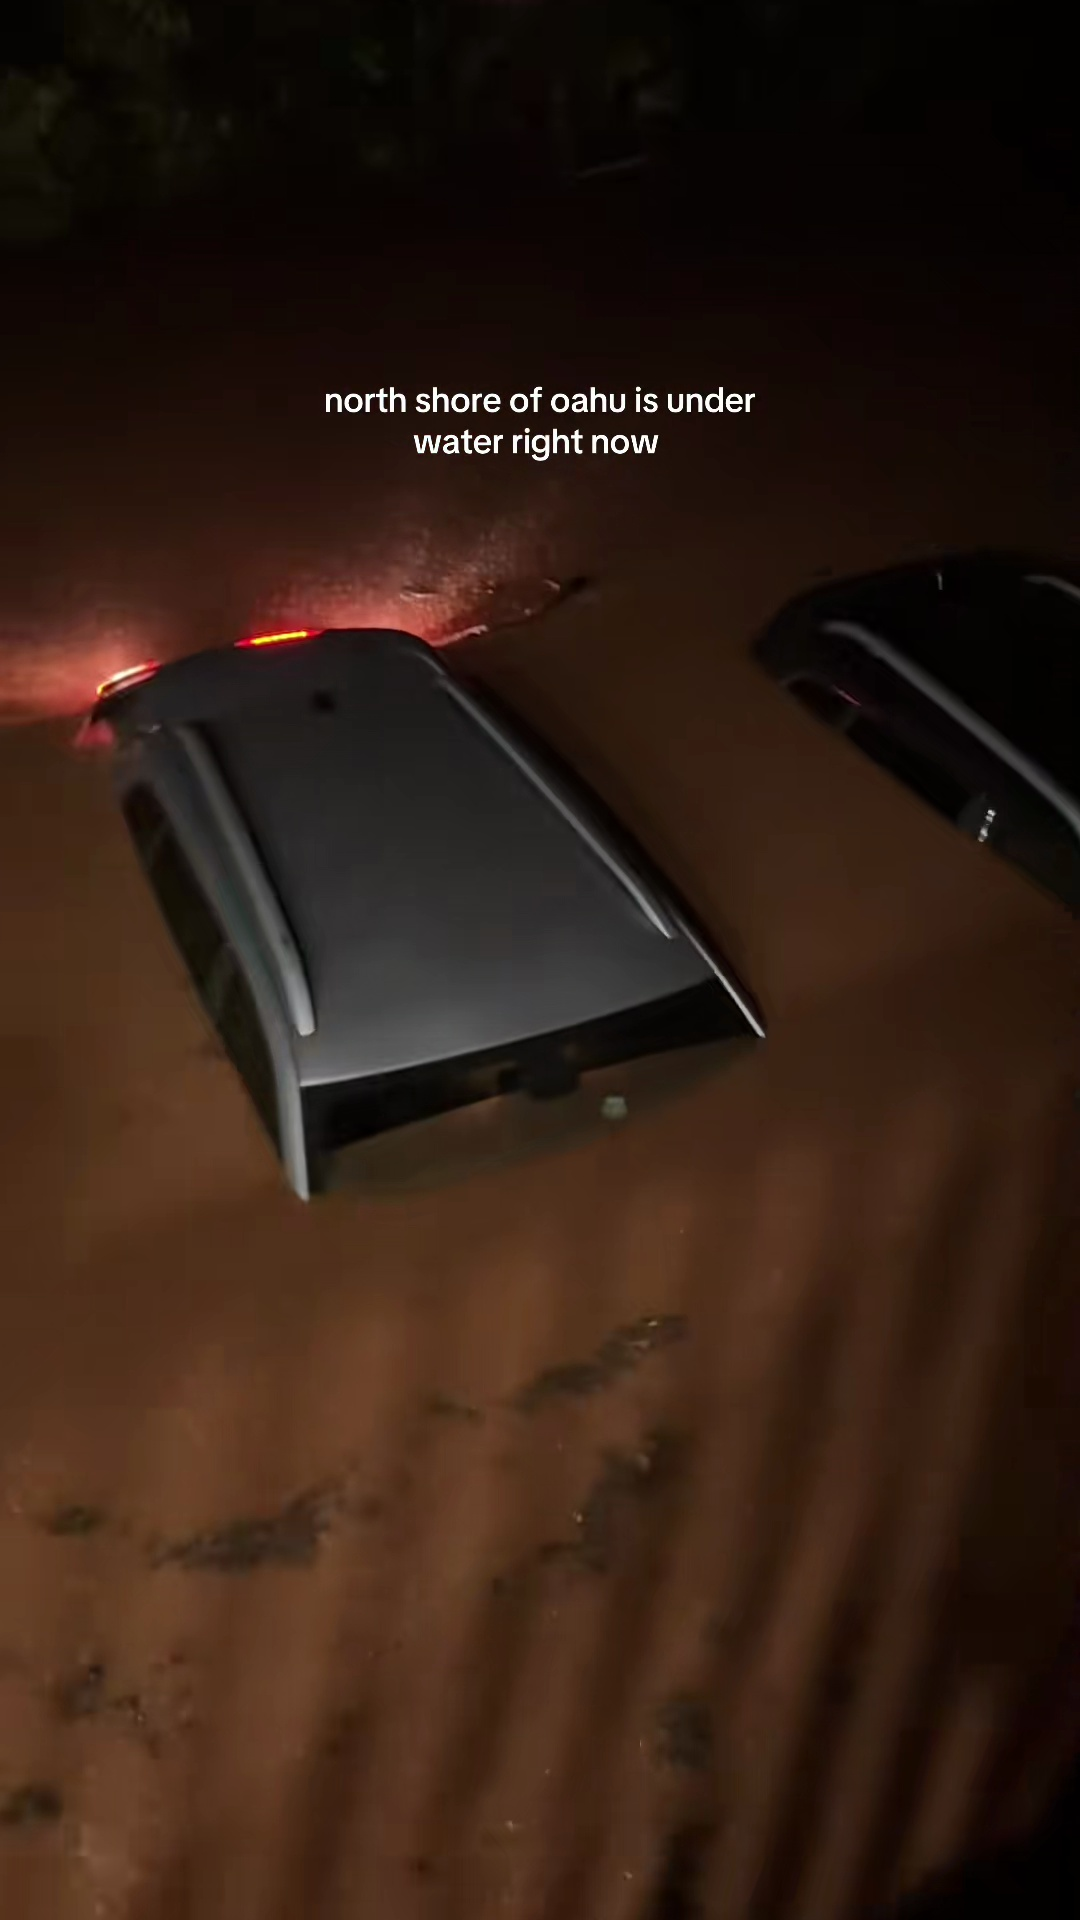
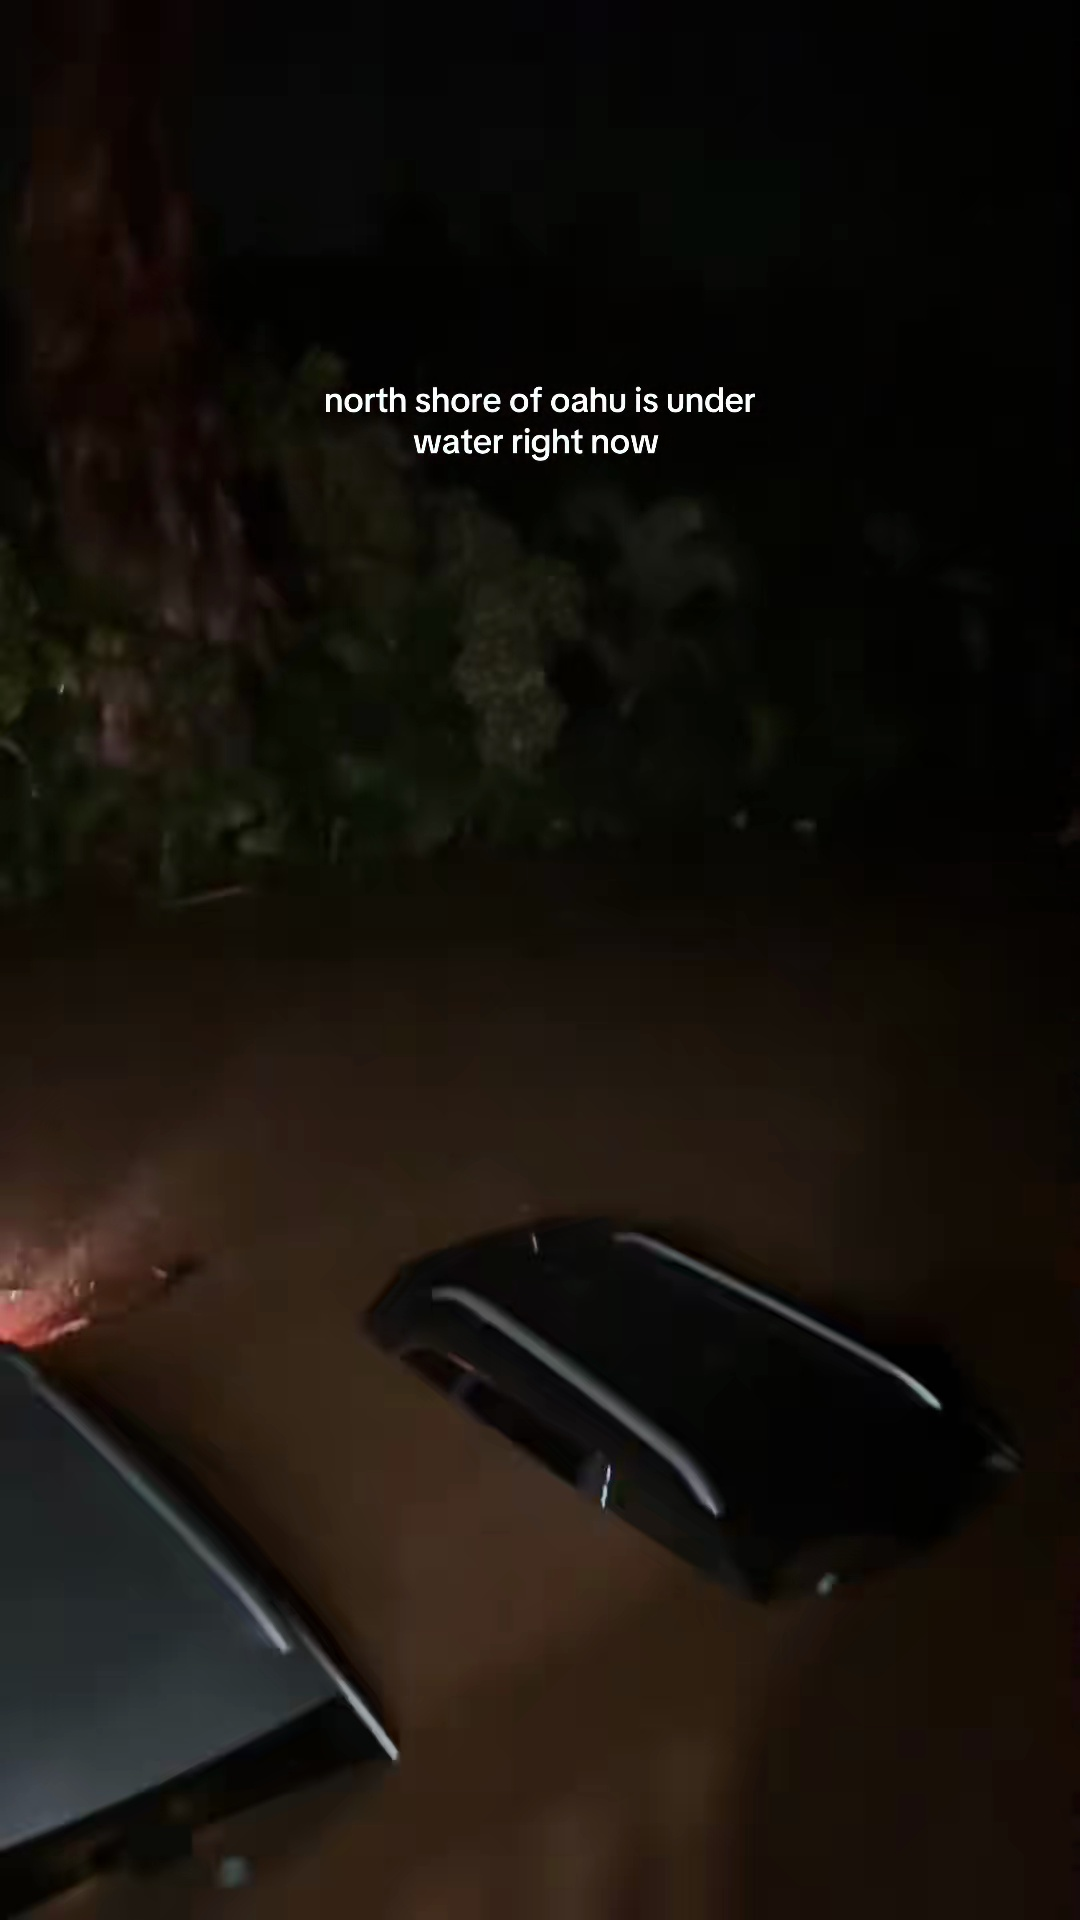
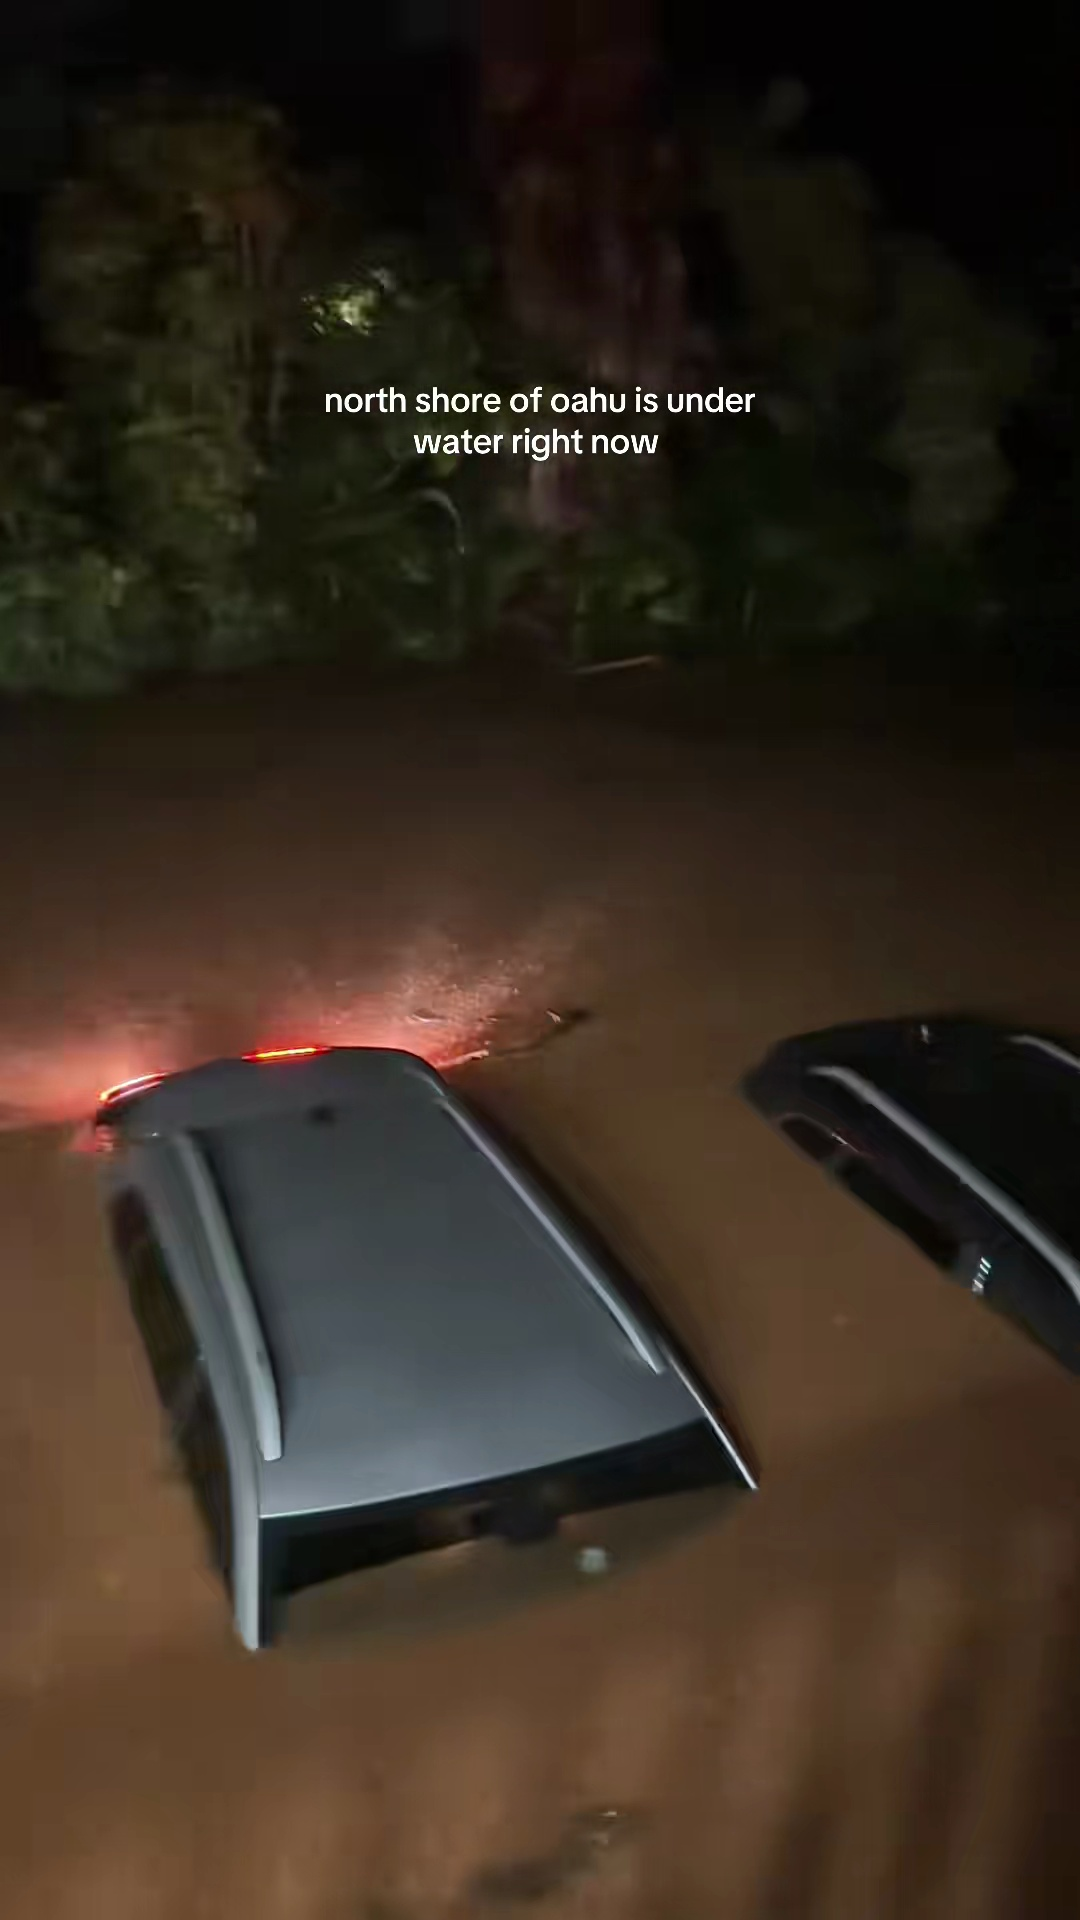
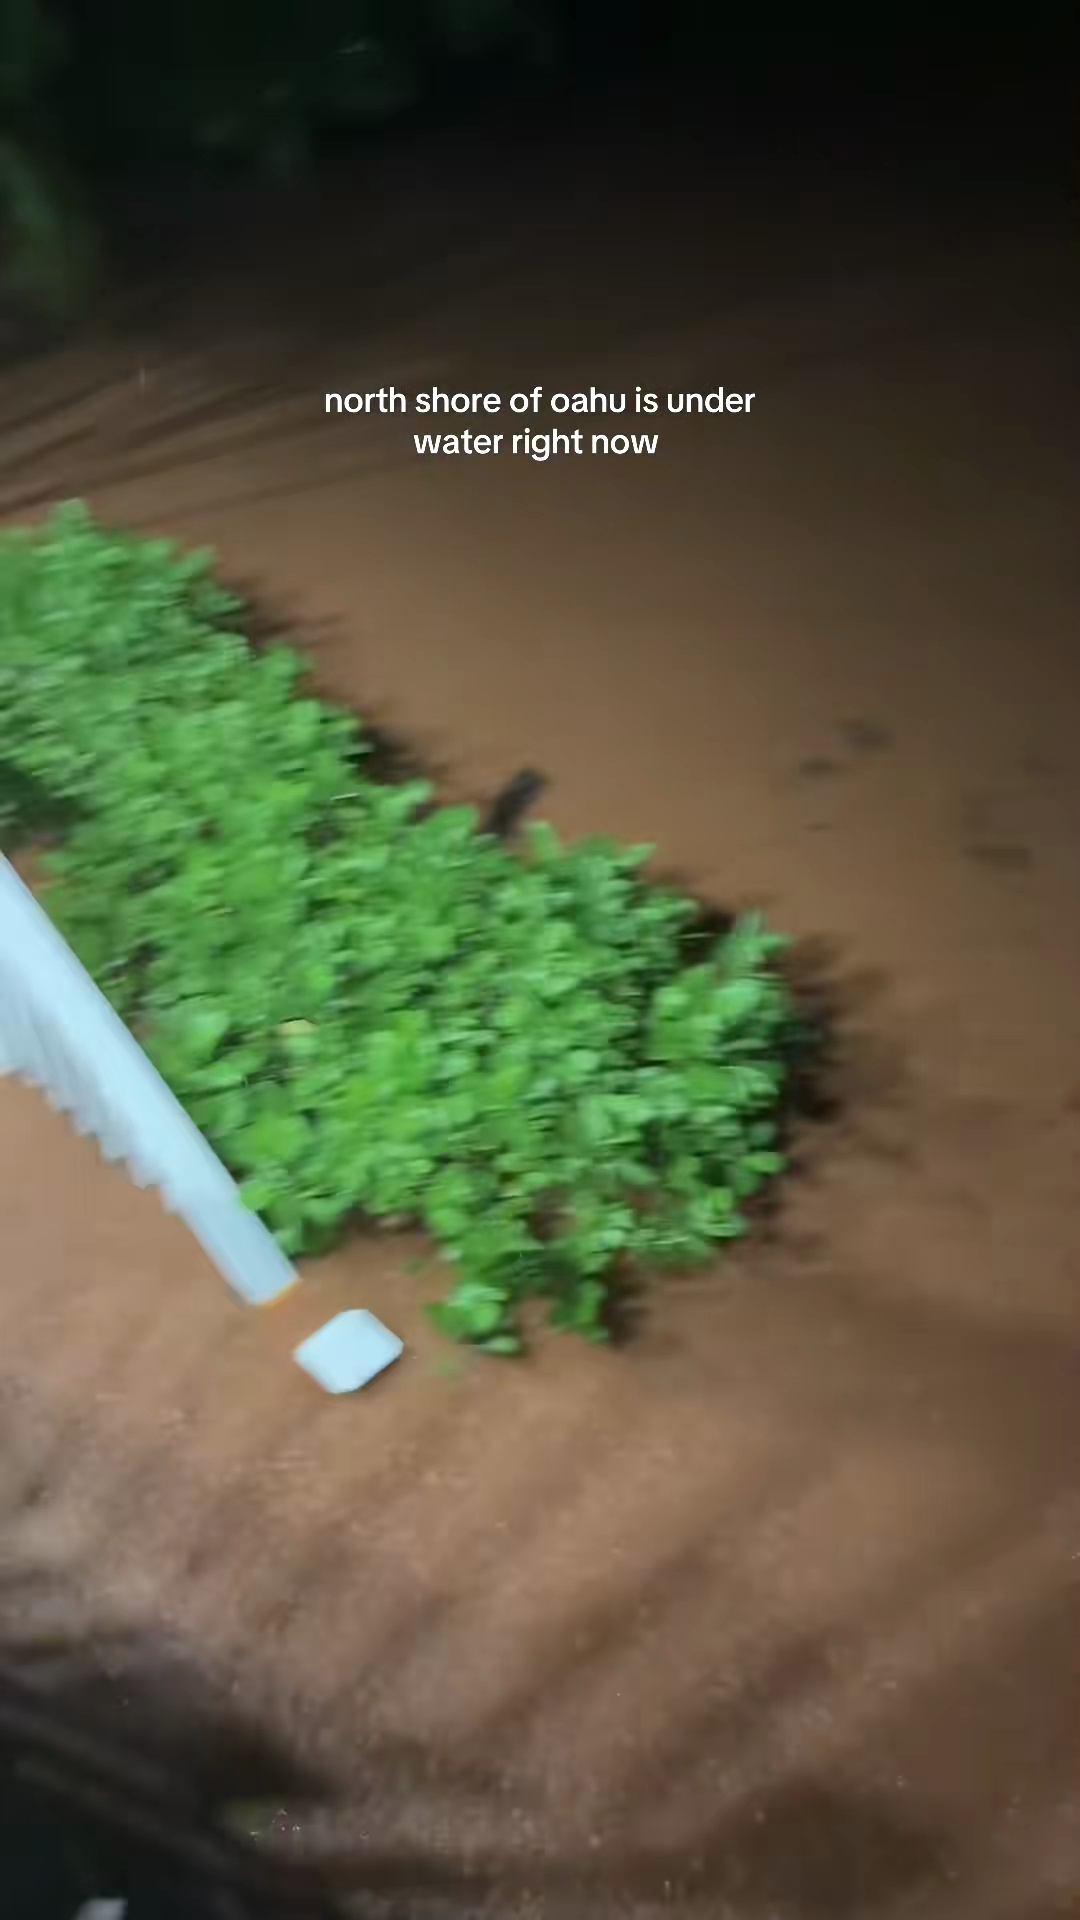
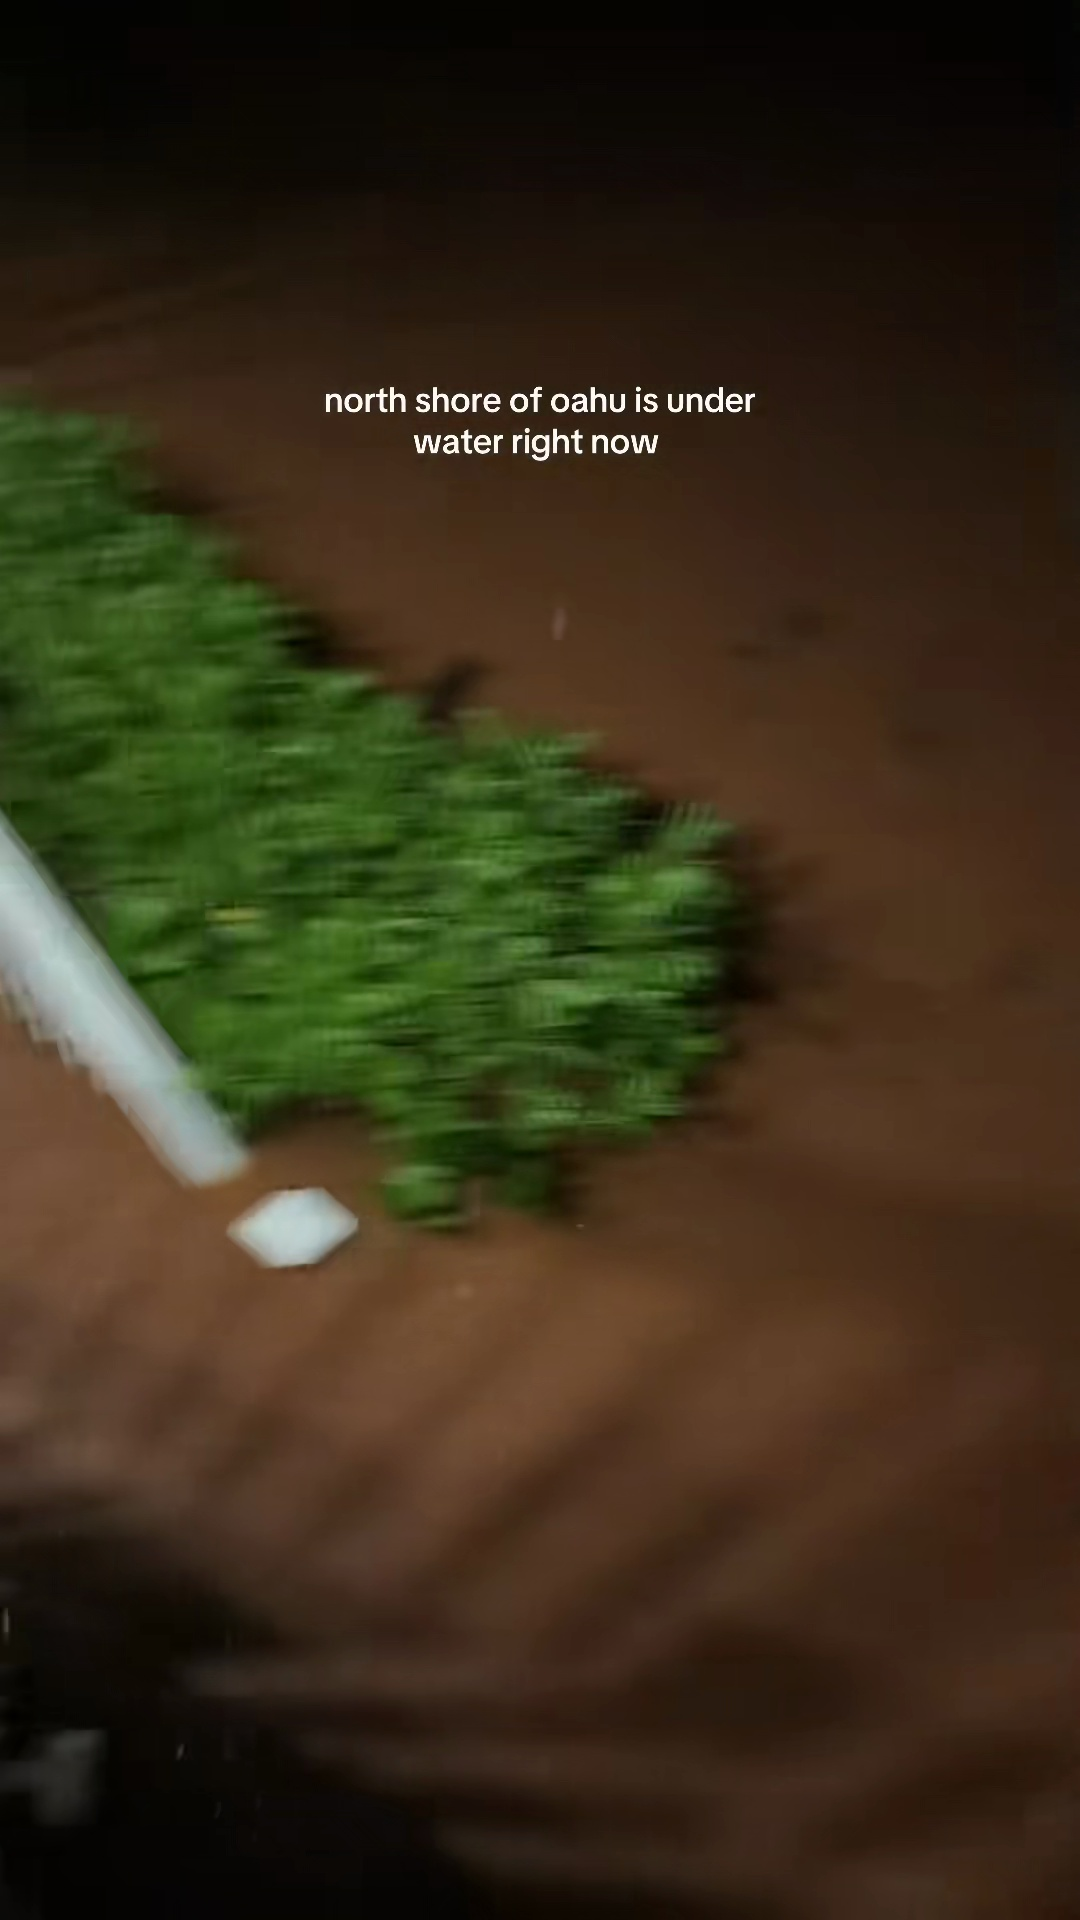
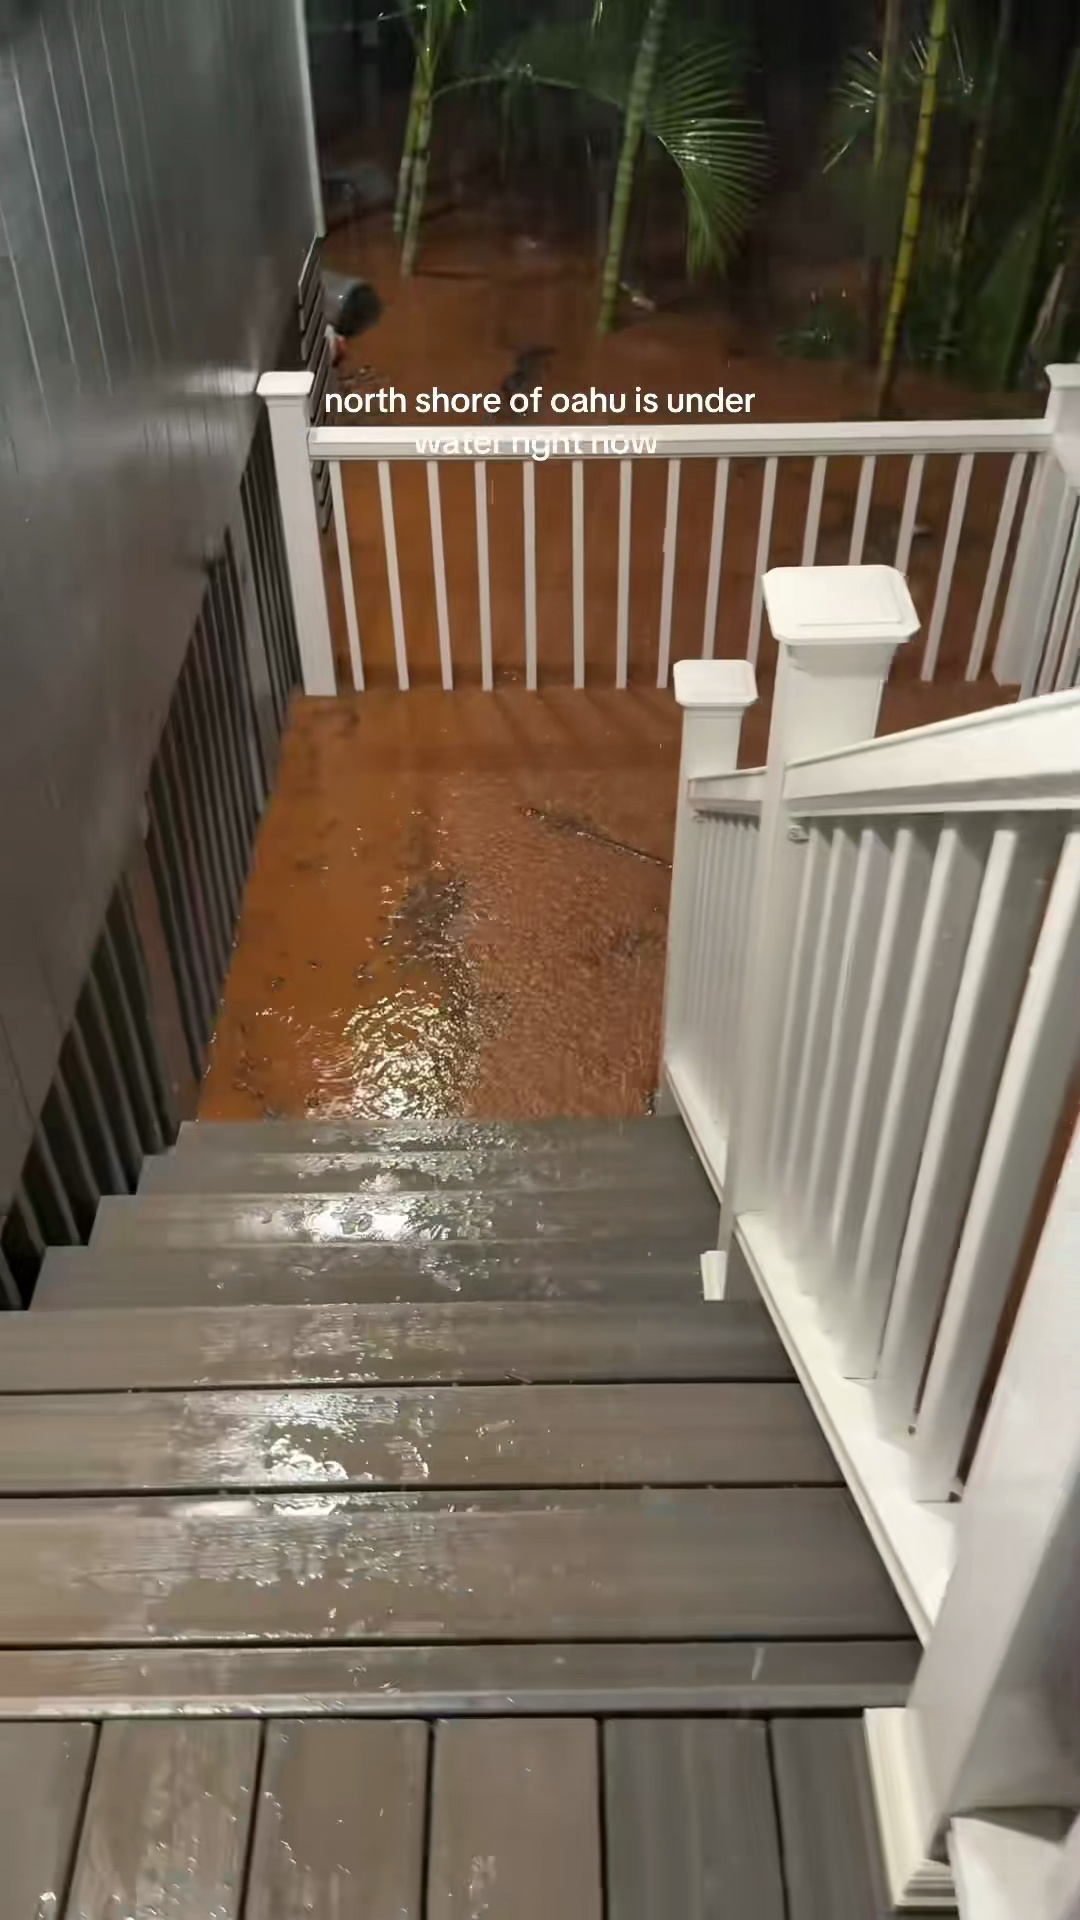
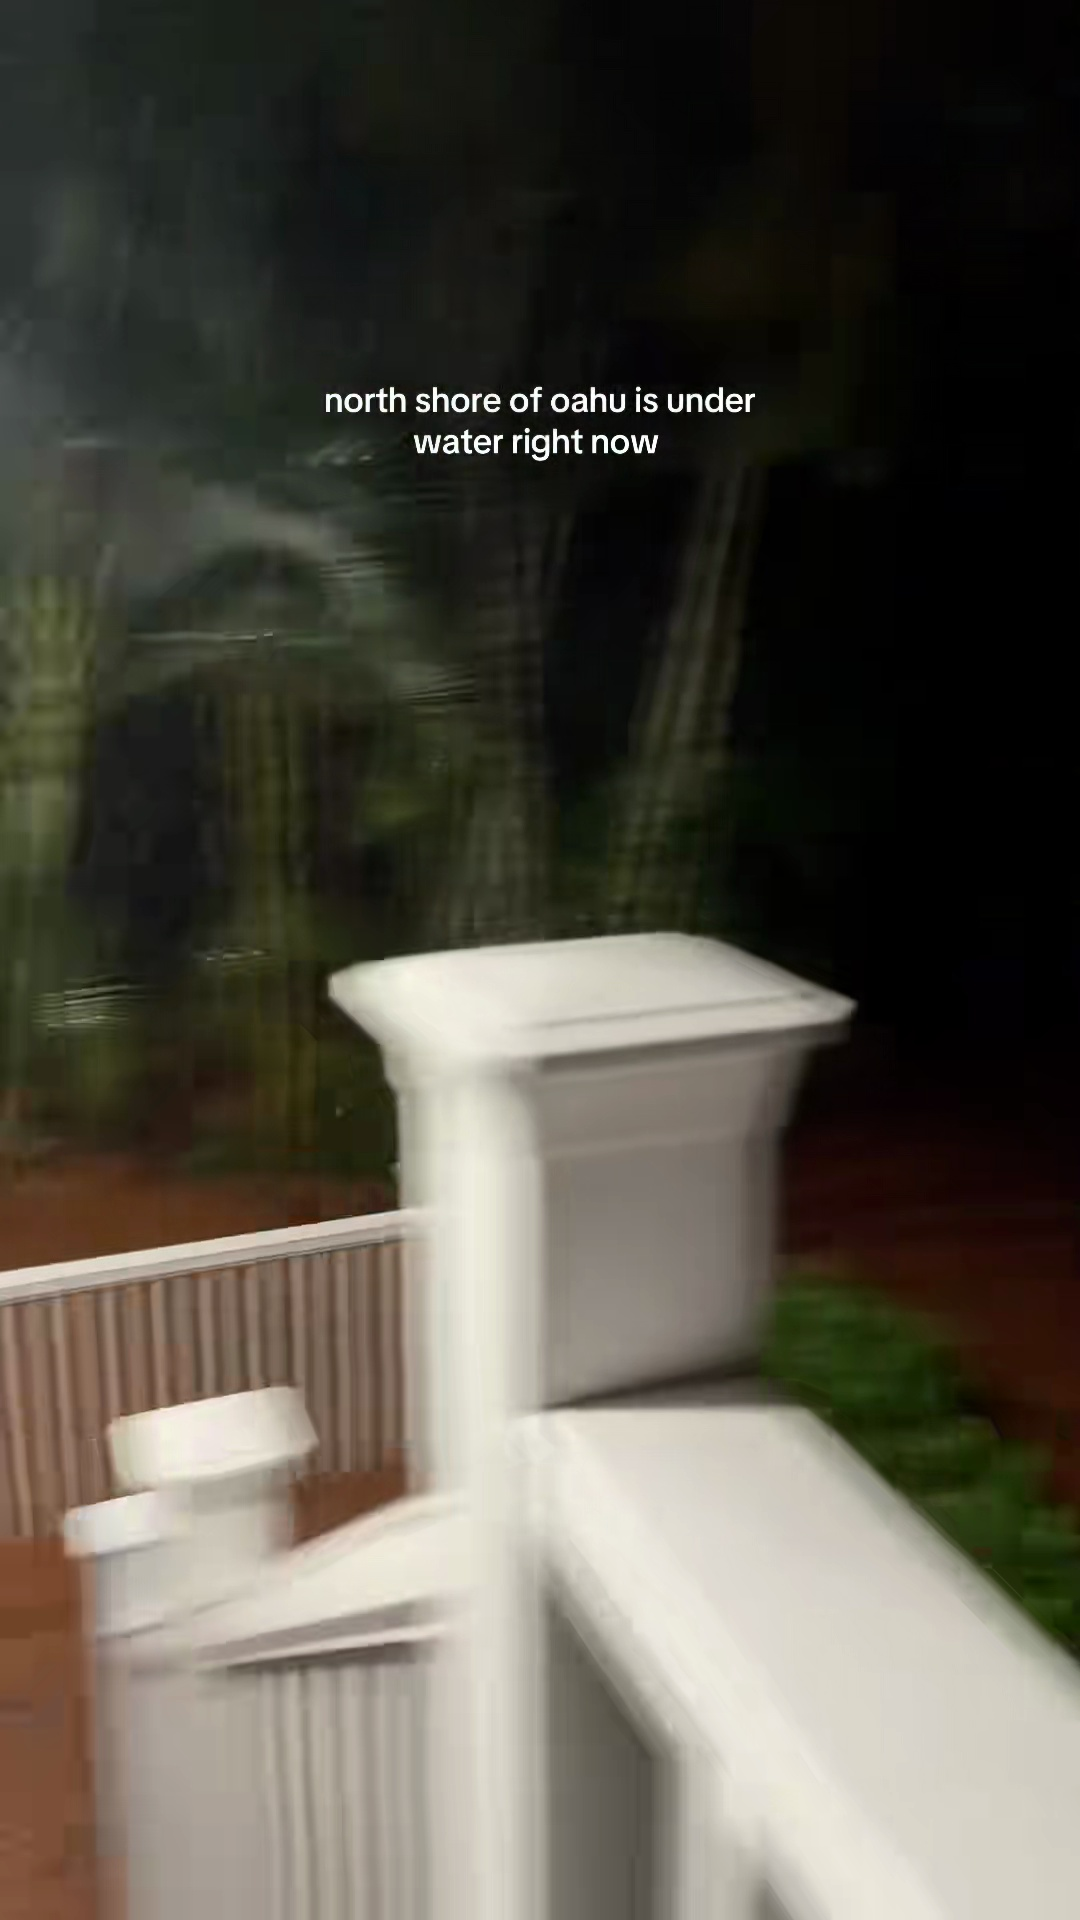
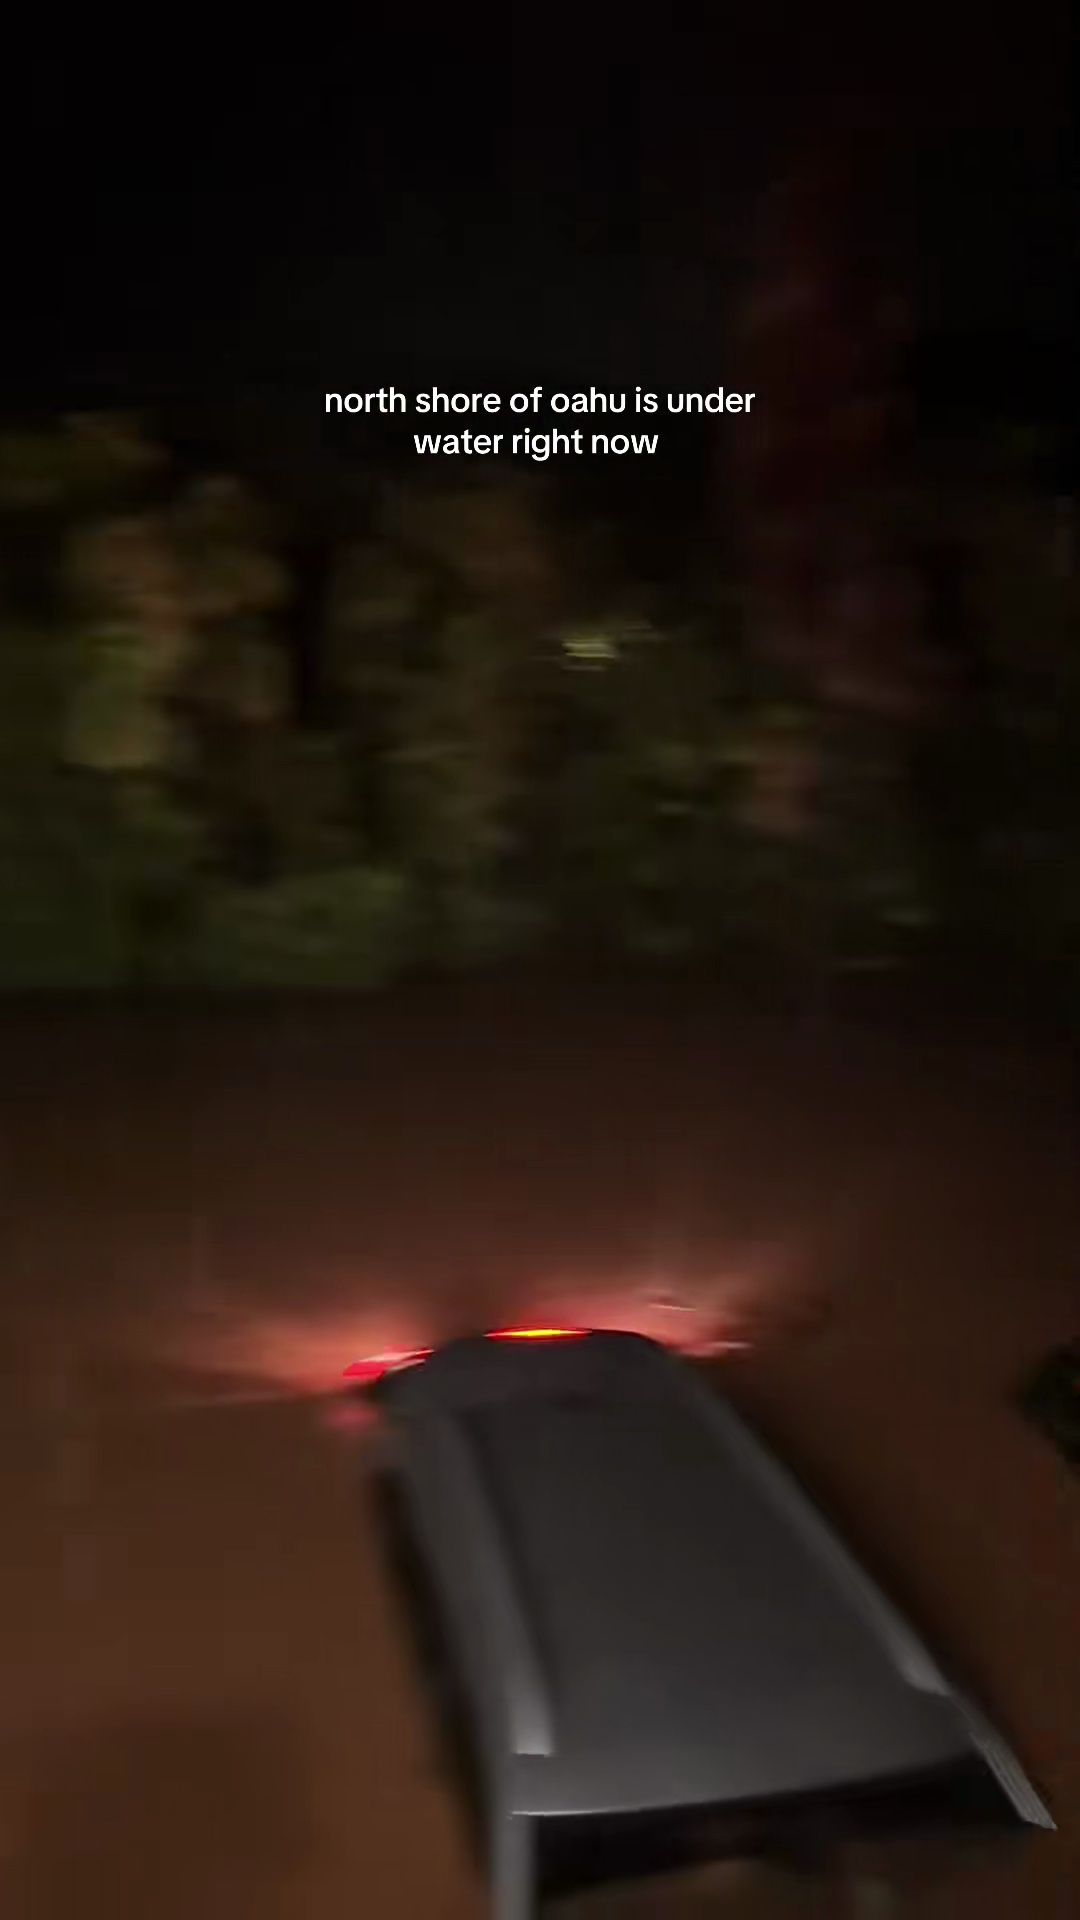
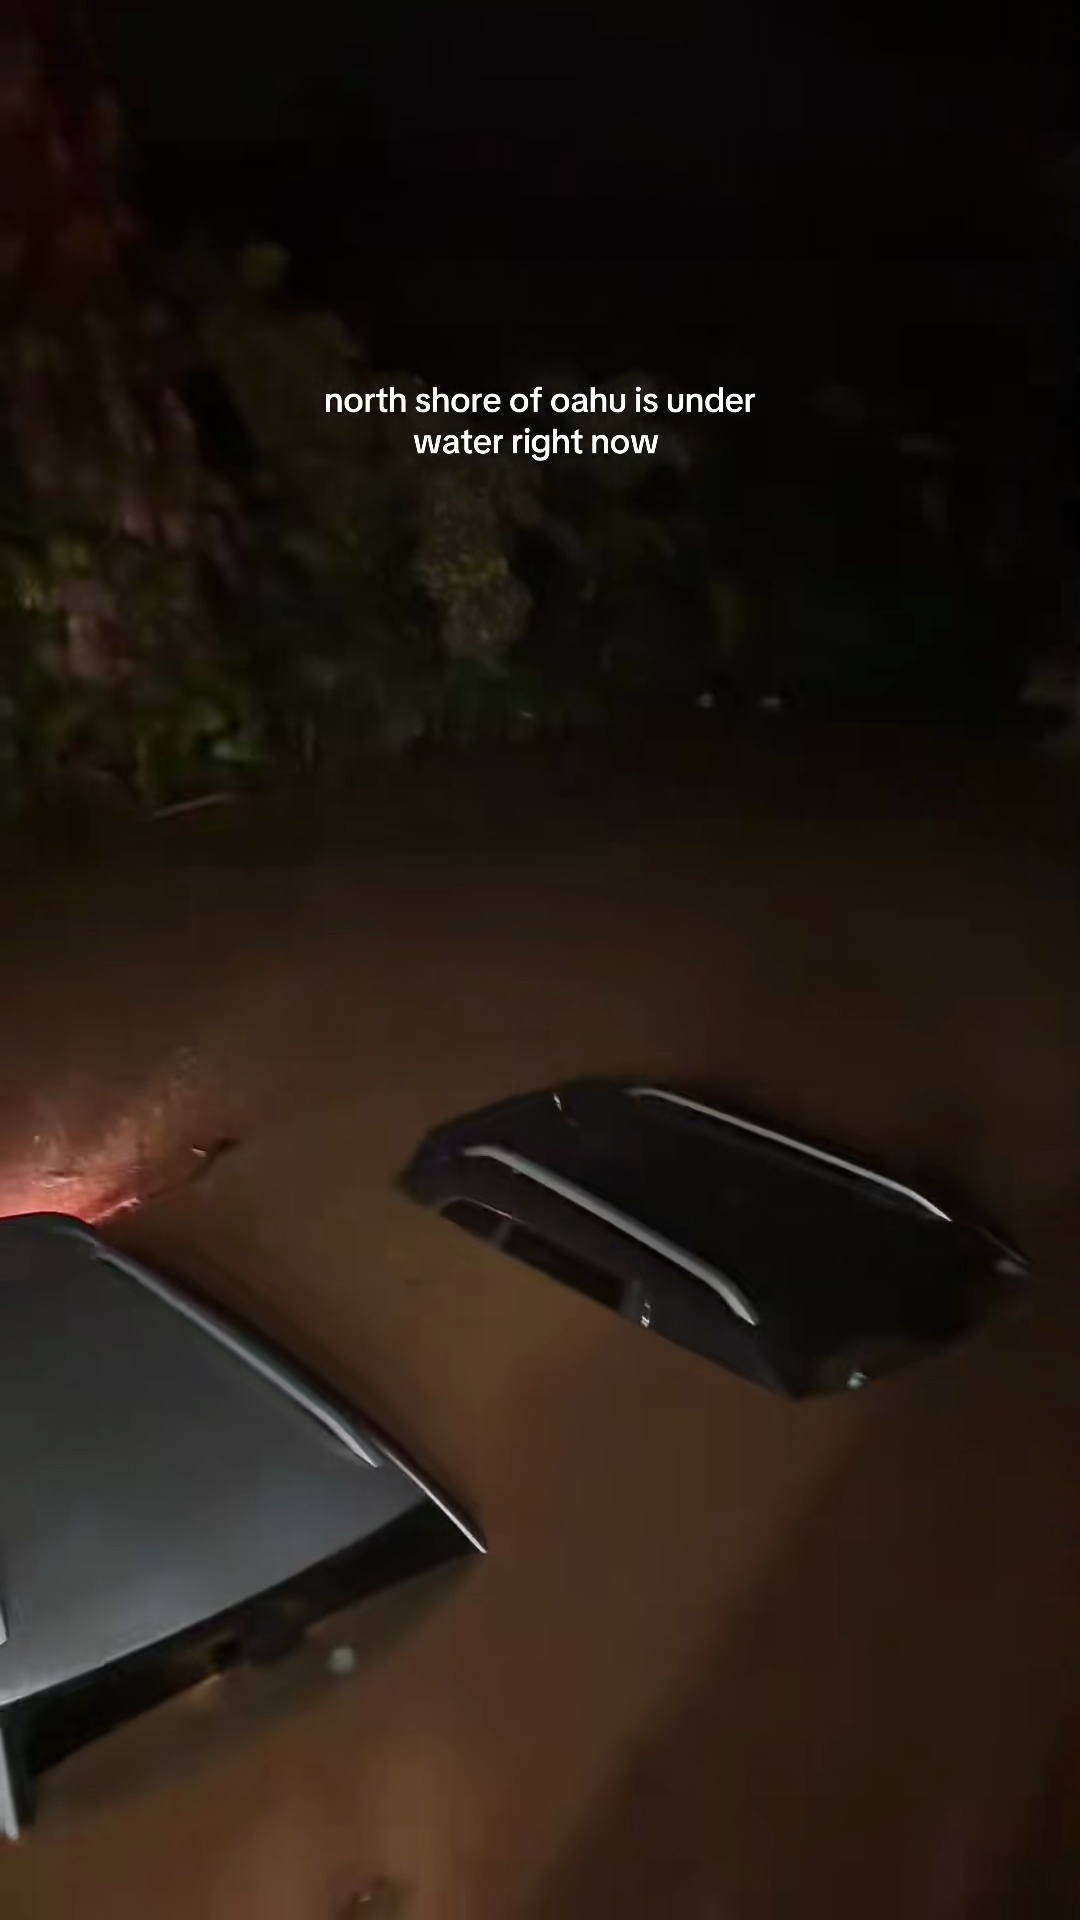

In [14]:

post_desc = yt_dlp_info['description']
post_title = yt_dlp_info['title']
post_id = yt_dlp_info['id']
video_path = post_title + " [" + post_id + "]" + ".mp4"
# uploader = FileUpload(accept='.mp4', multiple=False)
# display(uploader)
video_elements = prepare_gemma4_input(video_path)
print(video_path)
pprint(video_elements)


In [15]:
post_text = post_title + "\n" + post_desc
# with open(video_path, "rb") as f:
#     post_video = base64.b64encode(f.read()).decode()

additional_examples = ""

context_block = CONTEXT.substitute(
    taxonomy_json=taxonomy_json,
    full_taxonomy_json=full_taxonomy_json,
)

prompt = PROMPT_TEMPLATE.substitute(
    instruction=INSTRUCTION,
    context=context_block,
    output_formats=OUTPUT_FORMATS,
    ambiguous_classes=AMBIGUOUS_CLASSES,
    stock_examples=STOCK_EXAMPLES,
    additional_examples=additional_examples,
    post=post_text
)

# This works with gemini
# question = HumanMessage(content=[
#   {
#         "type": "media",
#         "mime_type": "video/mp4",
#         "data": post_video,
#   },
#   {
#         "type": "text",
#         "text": prompt
#   }
# ])
# display(video_elements)
formatted_prompt = {"type": "text", "text": prompt}
question = HumanMessage(content=[formatted_prompt] + video_elements)
# pprint(question)
response = llm.invoke([question], config=config)
# pprint(response.content)
# response = agent.invoke({"messages": [question]}, config)
# pprint(response["messages"][-1])

In [16]:
pprint(response.content)

('```json\n'
 '{\n'
 '  "text": "a loud crash then a massive flash flood #flashflood #hawaii #oahu '
 '#no...",\n'
 '  "type": [\n'
 '    "Other"\n'
 '  ],\n'
 '  "explanation": "The video sequence provides visual evidence of a flash '
 'flood event in a residential area on the North Shore of Oahu, showing water '
 'covering the ground and reaching vehicles and the sidewalk. This content is '
 'documentation of a natural disaster event, not a specific request or offer '
 'of aid.",\n'
 '  "visual_evidence": "The images show significant flooding (flash flood) in '
 'a residential area on the North Shore of Oahu, with water covering the '
 'ground and reaching cars and the sidewalk.",\n'
 '  "confidence": 0.95,\n'
 '  "insufficient_visual_evidence": false\n'
 '}\n'
 '```')
